In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubham47/salary-data-dataset-for-linear-regression")

path += "\\Salary_data.csv"
print(path)

C:\Users\harry\.cache\kagglehub\datasets\shubham47\salary-data-dataset-for-linear-regression\versions\1\Salary_data.csv


In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [24]:
df = pd.read_csv(path)
print(df.head())

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [25]:
print(df.columns)

Index(['YearsExperience', 'Salary'], dtype='object')


In [26]:
print(df['YearsExperience'].values)
print(df['Salary'].values)

[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5]
[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [27]:
X = df[['YearsExperience']]
y = df[['Salary']]

Text(0.5, 0, 'Years Of Experience')

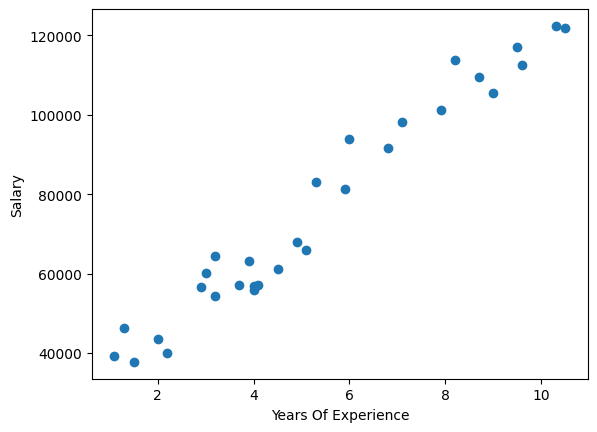

In [28]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.ylabel("Salary")
plt.xlabel("Years Of Experience")

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [30]:
model = LinearRegression()
model.fit(X_train,y_train) 
#or model.fit(df[['YearsExperience']],df[['Salary']])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0.5, 0, 'Years Of Experience')

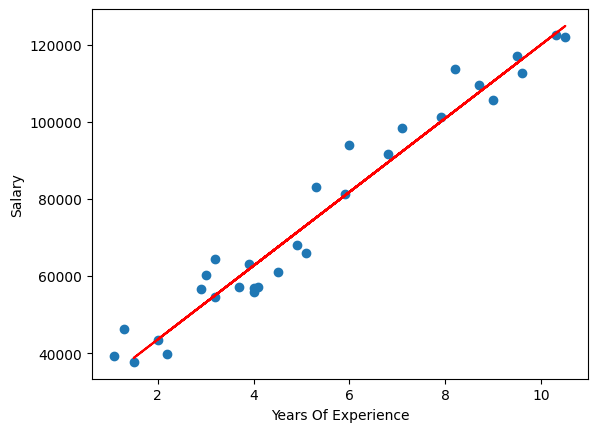

In [31]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.plot(X_train,model.predict(X_train),color='red')
plt.ylabel("Salary")
plt.xlabel("Years Of Experience")

In [32]:
m = model.coef_
c = model.intercept_
print("Slope :", m)
print("Intercept :", c)

Slope : [[9569.58688543]]
Intercept : [24393.16915195]


In [33]:
# predict = model.predict([[0]])
# print(predict)

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("Mean Absolute Error : ",mean_absolute_error(y_test,y_pred))

Mean Absolute Error :  6802.779572073898


In [36]:
print("Mean Squared Error : ",mean_squared_error(y_test,y_pred))

Mean Squared Error :  56137509.9978255


In [37]:
print("Root Mean Squared Error : ",root_mean_squared_error(y_test,y_pred))

Root Mean Squared Error :  7492.496913434499


In [38]:
r2 = r2_score(y_test,y_pred)
print("r2score : ", r2)

r2score :  0.8886956733784565


In [39]:
adR2 = 1 - (((1 - r2)*(len(X_test) - 1))/(len(X_test) - 1 - len(X_test.columns)))
print("Adjusted R2 Score : ", adR2)

Adjusted R2 Score :  0.8608695917230705


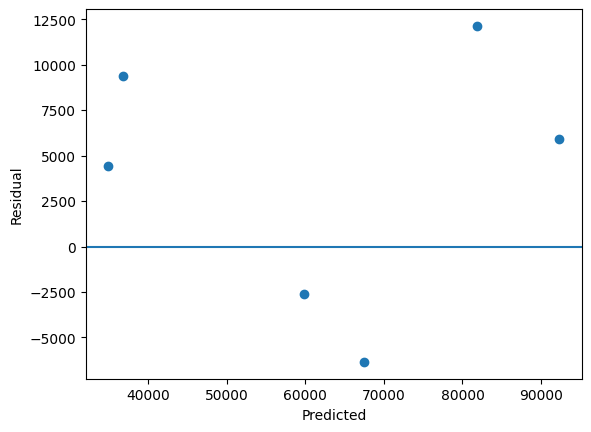

In [40]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

In [41]:
import pickle

with open("salary_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
